In [1]:
# start with a generating distribution h(x)
# draw a number of random sample as data
# fit these data with a parametric and non parametric model

In [4]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy import stats

from sklearn.neighbors import KernelDensity

from astropy.visualization import hist
from sklearn.mixture import GaussianMixture

In [5]:
# generate our data

random_state = np.random.RandomState(seed=0)
N = 2000 # number of data points
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
hx = lambda x: sum([f * stats.cauchy(mu, gamma).pdf(x) for (mu, gamma, f) in mu_gamma_f])
x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f * N), random_state = random_state) for (mu, gamma, f) in mu_gamma_f])

random_state.shuffle(x)
x = x[x > -10]
x = x[x < 30]

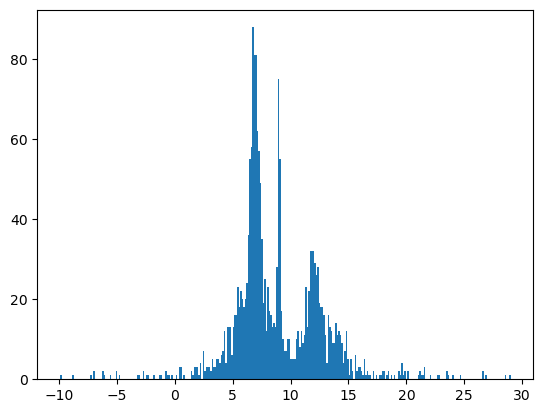

In [7]:
# histogram
plt.hist(x, bins=300);

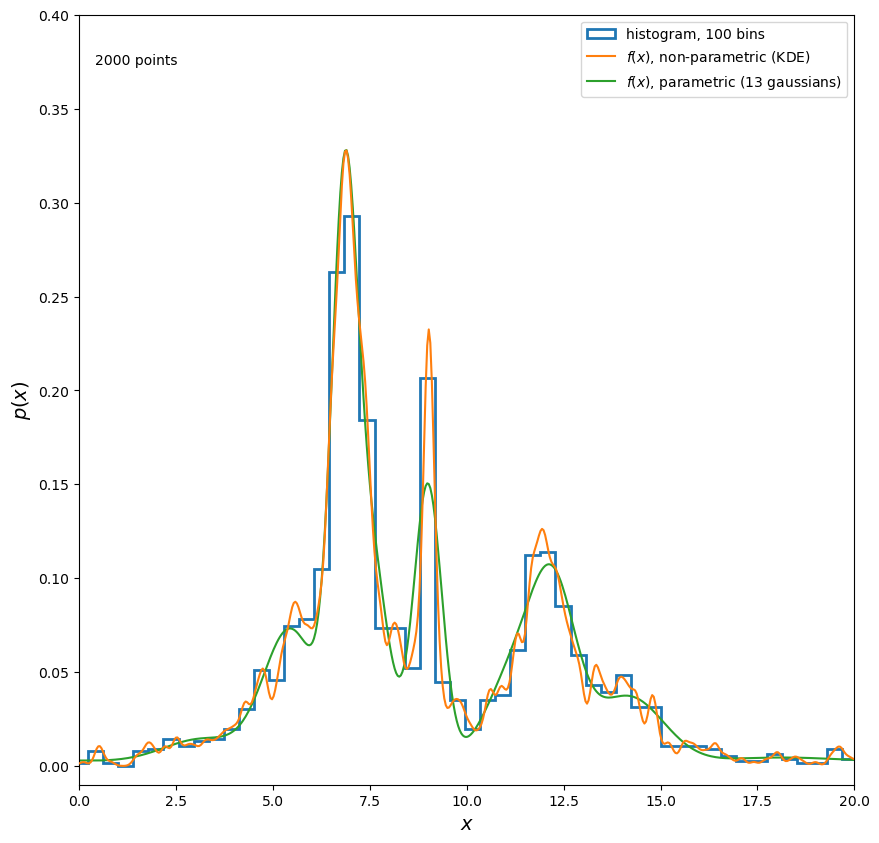

In [13]:
# plot the results
fig,ax = plt.subplots(figsize=(10,10))
xgrid = np.linspace(-10,30,1000)

# True distribution: you typically don't have it! Only have the samples!
if False :
    ax.plot(xgrid, hx(xgrid), ':', color='black', zorder=3, label ="$h(x)$, generating distribution")
    
# A simple histogram
# try changing the number of bins
if True: 
    ax.hist(x,density=True, color='C0', bins=100, histtype='step', lw= 2, label='histogram, 100 bins')
    
#something more sophisticated: kernel density estimations
#but try changin the bandwidth
if True:
    kde = KernelDensity(bandwidth=0.1, kernel='gaussian')
    kde.fit(x[:, None])
    dens_kde = np.exp(kde.score_samples(xgrid[:,None]))
    ax.plot(xgrid, dens_kde, '-', color='C1', zorder=3,label="$f(x)$, non-parametric (KDE)")

# use gaussian mixtures with a pre-defined number of clusters (13)
if True: 
    gmm = GaussianMixture(n_components=13).fit(x.reshape(-1,1))
    logprob = gmm.score_samples(xgrid.reshape(-1,1))
    fx = lambda j : np.exp(gmm.score_samples(j.reshape(-1,1)))
    ax.plot(xgrid, fx(np.array(xgrid)), '-',color='C2', label ="$f(x)$, parametric (13 gaussians)")
    
# plot cosmetics
ax.text(0.02,0.95, "%i points" % N, ha = 'left', va = 'top', transform=ax.transAxes)
ax.set_ylabel('$p(x)$', fontsize =14)
ax.legend(loc='upper right')
ax.set_xlabel('$x$', fontsize=14)
ax.set_xlim(0,20)
ax.set_ylim(-0.01, 0.4001)

plt.show()

In [ ]:
# for instance in a single point :
print(hx(9)) # h is the true distribution
print 